**Predizione delle performance scolastiche in base alle abitudini degli studenti**

Progetto di Programmazione di Applicazioni Data Intensive a.a. 2025/26:
Alan Barzanti, Marco Mondardini

L'obiettivo di questo progetto è ottenere una predizione delle performance scolastiche, misurata attraverso un voto, basandosi su dati ottenuti tramite delle rilevazioni delle abitudini degli studenti: in particolare si vuole analizzare, tra i vari fattori, come un hobby nello specifico, ovvero il gaming, influisca sulla produttività scolastica. A questo scopo abbiamo utilizzato il dataset "Gaming vs Academic Performance", da Kaggle.

Il dataset include 8000 istanze e 14 colonne: ogni riga rappresenta uno studente e ogni colonna fornisce un valore sulla specifica abitudine.

**Introduzione**

Procediamo al caricamento delle librerie fondamendali e del dataset:

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

import os.path

file = "./Gaming_Academic_Performance.csv";
if not os.path.exists(file):
    print("The dataset is missing.");

data = pd.read_csv(file);

Prima di tutto analizziamo il significato di ogni colonna:
- `student_id` — Identificativo univoco dello studente *(indice, sarà da escludere)*
- `age` — Età dello studente *(numerica continua)*, espressa in anni.
- `gender` — Genere dello studente *(categorica: Male / Female / Other)*.
- `gaming_hours` — Ore di gaming al giorno *(numerica continua)*, potenziale variabile negativa per i voti.
- `study_hours` — Ore di studio al giorno *(numerica continua)*, presumibilmente tra le più predittive per i voti.
- `sleep_hours` — Ore di sonno per notte *(numerica continua)*, influenza concentrazione e memoria.
- `attendance` — Percentuale di presenze a lezione *(numerica continua, 0–100)*, alta correlazione attesa con il voto.
- `gaming_genre` — Genere di videogioco preferito *(categorica: es. FPS, RPG, ...)*.
- `social_activity` — Livello di attività sociale *(numerica continua)*, può avere effetti sia positivi che negativi sulle performance.
- `device_usage` — Ore di utilizzo dei dispositivi elettronici *(numerica continua)*, uso generale di smartphone, tablet, PC.
- `reaction_time_ms` — Tempo di reazione in millisecondi *(numerica continua)*, misura la velocità di reazione, spesso influenzata dal gaming.
- `addiction_score` — Punteggio di dipendenza dal gaming *(numerica continua)*, valori più alti indicano dipendenza maggiore.
- `stress_level` — Livello di stress *(categorica ordinale: Low / Medium / High)*.
- `grades` — Voto finale dello studente *(numerica continua)* — è la nostra **variabile target**, non va usata come feature.

In [5]:
data.head(1)

,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,1,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,Low,86.459555


In [6]:
data.info(verbose=False, memory_usage="deep");

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Columns: 14 entries, student_id to grades
dtypes: float64(9), int64(2), object(3)
memory usage: 1.9 MB


Come possiamo vedere al momento l'utilizzo della memoria è di 1.9MB, ma possiamo ottimizzarlo:

In [9]:
data['gender'] = data['gender'].astype("category")
data['gaming_genre'] = data['gaming_genre'].astype("category")
data['stress_level'] = data['stress_level'].astype("category")
data = data.drop(columns=["student_id"])

In [12]:
data.info(verbose=False, memory_usage="deep");

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Columns: 13 entries, age to grades
dtypes: category(3), float64(9), int64(1)
memory usage: 649.4 KB


**Analisi esplorativa dei dati:**

In [16]:
data.describe()

,age,gaming_hours,study_hours,sleep_hours,attendance,social_activity,device_usage,reaction_time_ms,addiction_score,grades
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,19.983625,4.085773,5.460581,6.493453,79.886525,2.507790,7.586315,271.105839,9.908492,66.180776
std,2.587072,2.308801,2.575787,1.442656,11.580419,1.441128,2.710035,29.440675,5.035837,22.422024
min,16.000000,0.000000,1.000000,4.000000,60.000000,0.000000,1.100000,183.260000,-4.510000,0.000000
25%,18.000000,2.130000,3.240000,5.240000,69.780000,1.287500,5.560000,247.160000,5.920000,49.879843
50%,20.000000,4.130000,5.460000,6.505000,79.695000,2.500000,7.610000,270.475000,10.005000,67.070000
75%,22.000000,6.060000,7.660000,7.730000,90.100000,3.760000,9.600000,294.690000,13.860000,83.992223
max,24.000000,8.000000,10.000000,9.000000,100.000000,5.000000,13.950000,347.870000,23.160000,118.632936


Osserviamo la distribuzione dei voti:

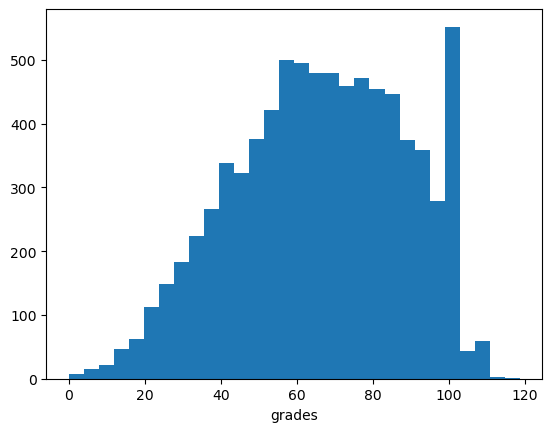

In [19]:
plt.hist(data["grades"], bins=30)
plt.xlabel("grades")
plt.show()

La distribuzione maggiore di voti si concentra tra il 60 e l'80, con una coda verso lo zero. Notiamo inoltre un altissimo numero di studenti con 100.

Osserviamo alcuni fattori che correlazione hanno con il voto finale:

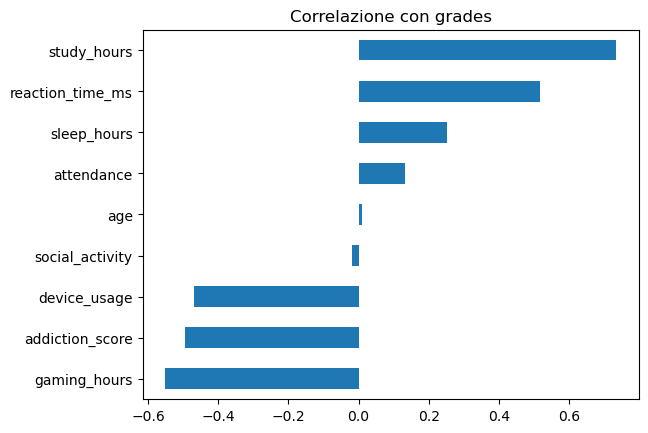

In [23]:
df_numeric = data.select_dtypes(include="number")
corr = df_numeric.corr()["grades"].drop("grades").sort_values()
corr.plot(kind="barh")
plt.title("Correlazione con grades")
plt.show()

Il tempo di studio, come prevedibile, è la variabile con la più alta correlazione positiva. Notiamo inoltre una strana correlazione positiva con il tempo di reazione, nonostante di solito maggiori tempi di reazione indicherebbero una minor prontezza. Le variabli correlate negativamente sono anch'esse le più prevedibili: tempo di utilizzo dei device, tempo di gioco e il valore relativo alla dipendenza da gioco. L'età e l'attività sociale non sembrano influenzare i voti.

Proviamo ad analizzare tramite dei grafici a dispersione le variabili con una correlazione maggiore:

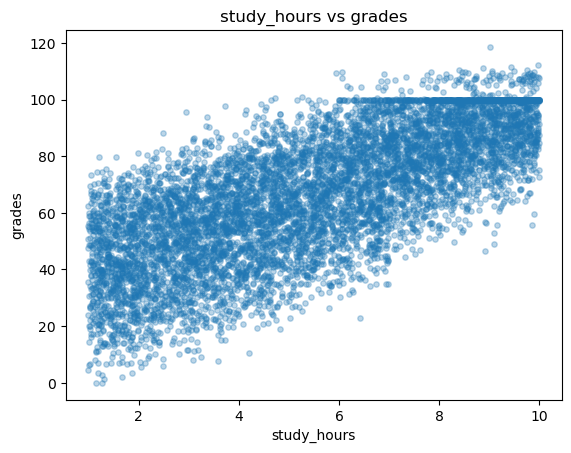

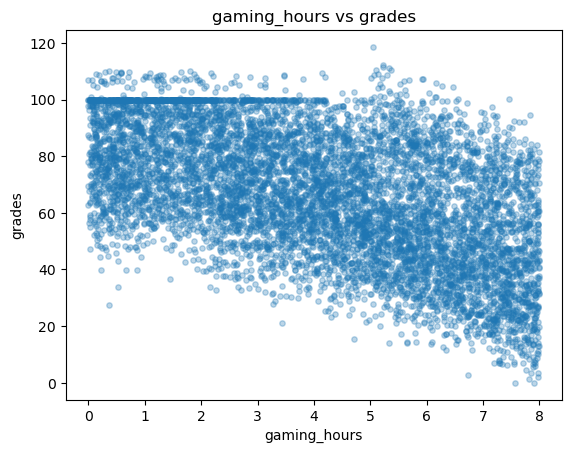

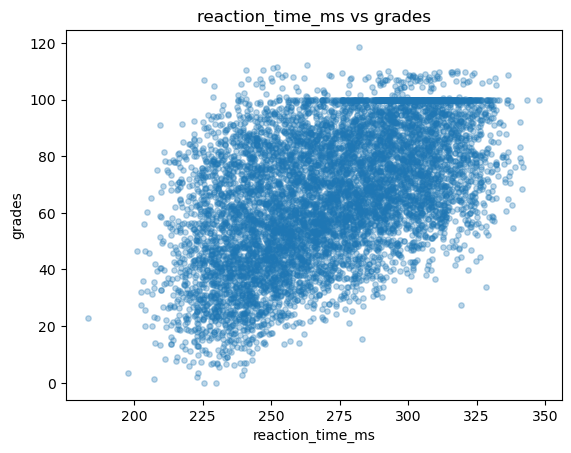

In [27]:
for col in ["study_hours", "gaming_hours", "reaction_time_ms"]:
    plt.scatter(data[col], data["grades"], alpha=0.3, s=15)
    plt.xlabel(col)
    plt.ylabel("grades")
    plt.title(f"{col} vs grades")
    plt.show()

Per quanto riguarda i tempi di studio e di gioco si vedono chiaramente delle relazioni relativamente lineari, la prima in positivo e la seconda in negativo. Per quanto riguarda il tempo di reazione invece la nuvola di punti è più dispersa e la relazione è meno chiara, nonostante l'alta correlazione vista prima.

Utilizziamo dei grafici a torta per visualizzare la distribuzione delle variabili categoriche:

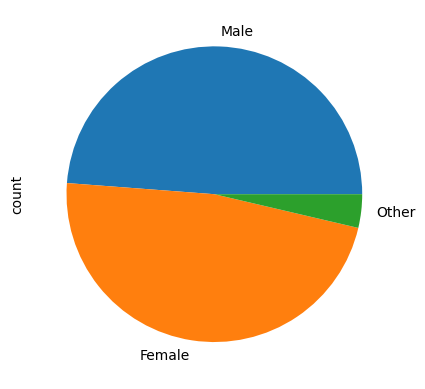

In [30]:
gender = data["gender"].value_counts()
gender.plot.pie()
plt.show()

Il dataset è abbastanza bilanciato.

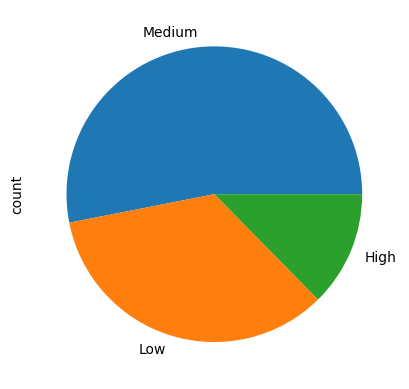

In [34]:
stress = data["stress_level"].value_counts()
stress.plot.pie()
plt.show()

la categoria più rappresentata è Medium, seguita da Low e poi High. La distribuzione è ragionevolmente equilibrata, nessuna categoria è quasi assente.

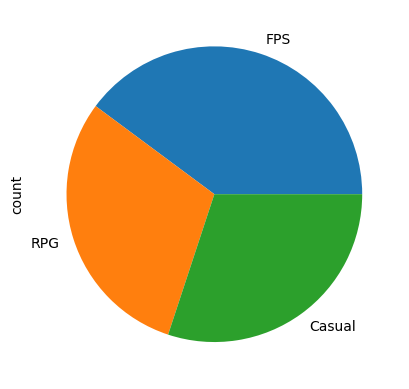

In [37]:
genre = data["gaming_genre"].value_counts()
genre.plot.pie()
plt.show()

i tre generi (FPS, RPG, Casual) sono distribuiti in modo abbastanza uniforme.

**Preparazione dei dati**

Come prima cosa dobbiamo rendere le variabili categoriche adatte per l'addestramento dei modelli: 
- utilizziamo One-hot encoding per gender e gaming_genre
- utilizziamo un mapping per stress_level

In [42]:
data = pd.get_dummies(data, columns=["gender", "gaming_genre"], drop_first=True)

In [43]:
stress_map = {"Low": 0, "Medium": 1, "High": 2}
data["stress_level"] = data["stress_level"].map(stress_map)
data["stress_level"] = data["stress_level"].astype(int)

In [44]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               8000 non-null   int64  
 1   gaming_hours      8000 non-null   float64
 2   study_hours       8000 non-null   float64
 3   sleep_hours       8000 non-null   float64
 4   attendance        8000 non-null   float64
 5   social_activity   8000 non-null   float64
 6   device_usage      8000 non-null   float64
 7   reaction_time_ms  8000 non-null   float64
 8   addiction_score   8000 non-null   float64
 9   stress_level      8000 non-null   int32  
 10  grades            8000 non-null   float64
 11  gender_Male       8000 non-null   bool   
 12  gender_Other      8000 non-null   bool   
 13  gaming_genre_FPS  8000 non-null   bool   
 14  gaming_genre_RPG  8000 non-null   bool   
dtypes: bool(4), float64(9), int32(1), int64(1)
memory usage: 687.6 KB


Come posssiamo vedere ora abbiamo una colonna di tipo booleani per ogni tipo possibile delle due variabile categoriche. Per quanto riguarda stress_level invece ora i valori low, medium e high sono diventati 0, 1 e 2.

Passiamo all'isolare la variabile target dalle feature:

In [47]:
X = data.drop(columns=["grades"])
y = data["grades"]

Ora dividiamo il dataset in dati di training e dati di test, utilizziamo una proporzione 70:30

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=42)

**Addestramento modelli**

**Modello 1: regressione lineare**

Per primo proviamo ad addestrare un modello di regressione lineare:

Importiamo le librerie:

In [88]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

Istanziamo il modello e addestriamolo

In [91]:
model_linear = LinearRegression()
model_linear.fit(X_train, y_train)

LinearRegression()

Calcoliamo la predizione

In [94]:
y_pred_linear = model_linear.predict(X_test)

Calcoliamo le performance del modello con misurazioni come: coefficiente di determinazione R², Mean Squared Error e errore relativo.

In [99]:
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)
err_rel_linear = np.mean(np.abs((y_test - y_pred_linear) / y_test))
print(f"MSE: {mse_linear:.2f}")
print(f"R²: {r2_linear:.2f}")
print(f"Errore relativo medio: {err_rel_linear:.2f}")

MSE: 47.28
R²: 0.90
Errore relativo medio: 0.10


Il modello di regressione lineare ottiene un R² di 0.90, un risultato molto buono. L'errore quadratico medio (MSE) è 47.28, che corrisponde a un errore medio di circa 6.9 punti di voto. L'errore relativo medio di 0.10 indica che in media il modello sbaglia del 10% rispetto al valore reale. Questi risultati confermano che le relazioni tra le variabili e il voto sono abbastanza lineari, come già suggerito dall'analisi esplorativa.

Ora vediamo quali variabili hanno contribuito in maniera positiva o negativa:

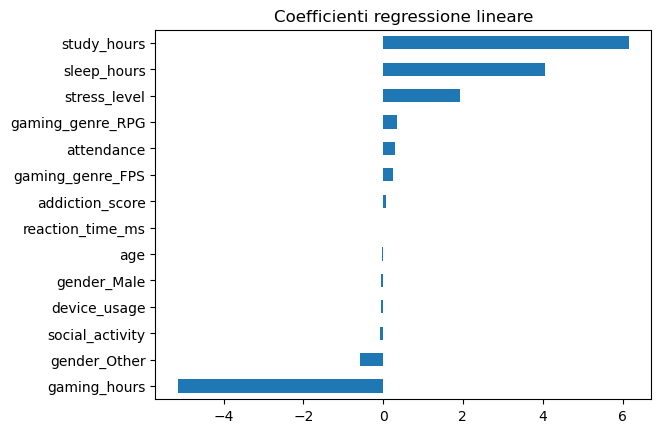

In [71]:
coef = pd.Series(model_linear.coef_, index=X_train.columns).sort_values()
coef.plot(kind="barh")
plt.title("Coefficienti regressione lineare")
plt.show()

Alcuni fattori sono esattamente quelli che ci aspettavamo: study_hours, sleep_hours e gaming_hours sono le variabili che, come prevedibile, influenzano di più il risultato. Altre cose interessanti che possiamo notare sono: stress_level, sorprendentemente valori di stress più alto aumentano le peformance, gender_Other, sembra stranamente avere un'influenza negativa ma è un dato molto poco rappresentato nel dataset, di conseguenza i risultati non sono attendibili. Altre variabilil come age, gender_Male, device_usage, social_activity e reaction_time_ms sono praticamente irrilevanti (anche quest'ultima nonostante nell'analisi esplorativa sembrava correlata).

Proviamo ora a visualizzare graficamente la retta e i punti in un grafico a dispersione:

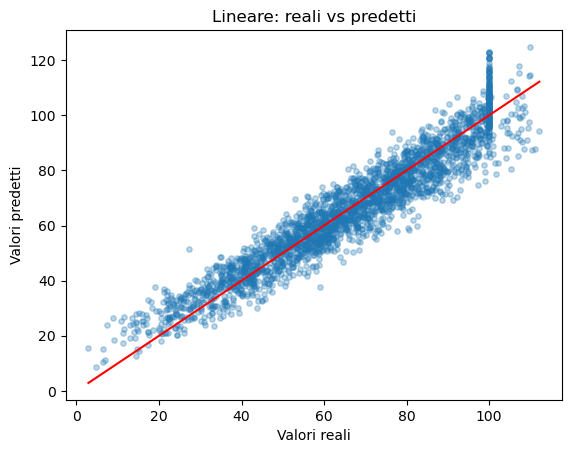

In [77]:
plt.scatter(y_test, y_pred_linear, alpha=0.3, s=15)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.xlabel("Valori reali")
plt.ylabel("Valori predetti")
plt.title("Lineare: reali vs predetti")
plt.show()

I punti seguono abbastanza fedelmente la retta rossa (che rappresenta la predizione perfetta), confermando il buon risultato ottenuto con R² = 0.90. La dispersione è uniforme lungo tutta la retta, senza zone dove il modello sbaglia sistematicamente di più. Si nota tuttavia la colonna verticale di punti in corrispondenza di grades = 100, anomalia già osservata in fase di analisi esplorativa, che il modello fatica a predire correttamente producendo stime sia sopra che sotto il valore reale.

In [107]:
from sklearn.model_selection import cross_val_score

# Cross validation regressione lineare
scores_linear = cross_val_score(model_linear, X, y, cv=5, scoring="r2")
print(f"R² medio: {scores_linear.mean():.2f}")
print(f"Deviazione standard: {scores_linear.std():.2f}")

R² medio: 0.91
Deviazione standard: 0.00


.....

In [59]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

model_poly = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("linear", LinearRegression())
])

model_poly.fit(X_train, y_train)

y_pred_poly = model_poly.predict(X_test)

mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)
err_rel_poly = np.mean(np.abs((y_test - y_pred_poly) / y_test))

print(f"MSE: {mse_poly:.2f}")
print(f"R²: {r2_poly:.2f}")
print(f"Errore relativo medio: {err_rel_poly:.2f}")

MSE: 39.41
R²: 0.92
Errore relativo medio: 0.09
